In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

训练开始 | 设备: cuda | 模式: 正常训练 (无扰动)


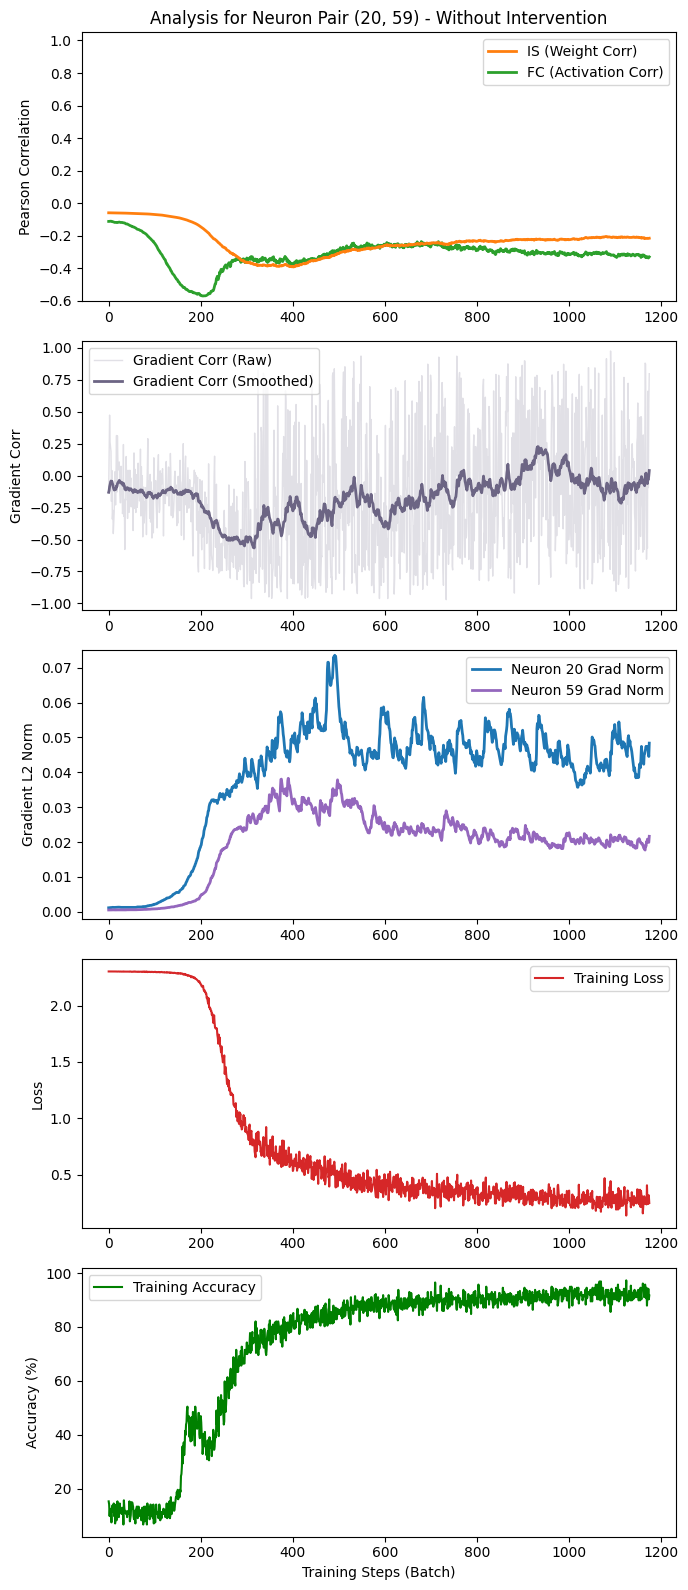

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

import warnings
warnings.filterwarnings('ignore')

# 1. 基础设置与模型定义
def set_seed(seed=42):
    random.seed(seed)                
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False   

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10, activation='relu', init_method='normal'):
        super(MLP, self).__init__()
        self.hidden_dims = hidden_dims
        self.linear_layers = nn.ModuleList()
        layers = []

        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()
        
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(act_fn)
            current_dim = h_dim
        
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        
        self.network = nn.Sequential(*layers)
        
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_method == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

def load_fashion_mnist(batch_size=256):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])
    train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

def load_mnist(batch_size=128):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=transform, download=True
    )
    # test_dataset = torchvision.datasets.MNIST(
    #     root='./data', train=False, transform=transform, download=True
    # )
    # batch_size = int(len(train_dataset)/2)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader

# 2. 核心干预逻辑：强制功能同步 Hook
class ForcedSynchronyIntervention:
    def __init__(self, target_idx_A=0, target_idx_B=1, start_step=50, end_step=300, noise_strength=2.0):
        self.target_idx_A = target_idx_A
        self.target_idx_B = target_idx_B
        self.start_step = start_step
        self.end_step = end_step
        self.noise_strength = noise_strength
        self.current_step = 0

    def hook_fn(self, module, input, output):
        if self.start_step <= self.current_step <= self.end_step:
            new_output = output.clone()
            batch_size = output.size(0)
            device = output.device
            
            shared_noise = torch.randn(batch_size, device=device) * self.noise_strength
            positive_shared_noise = torch.abs(shared_noise)
            
            new_output[:, self.target_idx_A] += positive_shared_noise
            new_output[:, self.target_idx_B] += positive_shared_noise
            
            return new_output
        else:
            return output

# 3. 带有干预控制和指标追踪的训练循环
def train_model(model, train_loader, epochs=5, learning_rate=0.05, apply_intervention=True, target_pair=(0, 1), intervention_start=50, intervention_end=300):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    model_states = []
    losses = []
    accuracies = []
    grad_corrs = []
    grad_norms_A = [] # 新增：存储神经元A的梯度范数
    grad_norms_B = [] # 新增：存储神经元B的梯度范数
    
    if apply_intervention:
        intervention = ForcedSynchronyIntervention(target_idx_A=target_pair[0], target_idx_B=target_pair[1], start_step=intervention_start, end_step=intervention_end)
        hook_handle = model.network[3].register_forward_hook(intervention.hook_fn)
        print(f"训练开始 | 设备: {device} | 模式: 开启靶向强制同步扰动")
    else:
        print(f"训练开始 | 设备: {device} | 模式: 正常训练 (无扰动)")

    current_step = 0
    for epoch in range(epochs):
        model.train()
        for batch_idx, (data, targets) in enumerate(train_loader):
            current_step += 1
            if apply_intervention:
                intervention.current_step = current_step
                
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward() 

            # --- 提取目标神经元的权重梯度 ---
            grad_w = model.linear_layers[1].weight.grad
            if grad_w is not None:
                g_A = grad_w[target_pair[0]].detach().cpu().numpy()
                g_B = grad_w[target_pair[1]].detach().cpu().numpy()
                
                # 计算相关性
                corr = np.nan_to_num(np.corrcoef(g_A, g_B)[0, 1])
                grad_corrs.append(corr)
                
                # 新增：计算并存储梯度的L2范数 (代表梯度的大小/变化幅度)
                grad_norms_A.append(np.linalg.norm(g_A))
                grad_norms_B.append(np.linalg.norm(g_B))
            else:
                grad_corrs.append(0.0)
                grad_norms_A.append(0.0)
                grad_norms_B.append(0.0)
            # --------------------------------------------------

            optimizer.step()

            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            model_states.append(state)
            
            losses.append(loss.item())
            _, predicted = outputs.max(1)
            acc = 100. * predicted.eq(targets).sum().item() / targets.size(0)
            accuracies.append(acc)
            
    if apply_intervention:
        hook_handle.remove()
        
    return model_states, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B

# 引入必要的平滑函数（可以放在文件开头或其他辅助函数区域）

def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points


# 4. 综合图表绘制
def analyze_comprehensive_effect(models, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B, train_loader, target_pair=(0,1), apply_intervention=True, start_step=50, end_step=300, intervention_obj=None, smooth_factor=0.95):
    sampled_steps = list(range(len(models)))
    target_IS_values = []
    target_FC_values = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data_iter = iter(train_loader)
    fixed_data, _ = next(data_iter)
    fixed_data = fixed_data.to(device).view(fixed_data.size(0), -1)
    
    template_model = MLP(input_size=784, hidden_dims=[100, 100], activation='relu')
    template_model.to(device)
    template_model.eval()
    
    if apply_intervention and intervention_obj is not None:
        hook_handle = template_model.network[3].register_forward_hook(intervention_obj.hook_fn)
    
    for i in range(len(models)):
        state = models[i]
        current_step = i + 1 
        
        if apply_intervention and intervention_obj is not None:
            intervention_obj.current_step = current_step
            
        weights = state['linear_layers.1.weight'].cpu().numpy()
        w_A, w_B = weights[target_pair[0]], weights[target_pair[1]]
        target_IS_values.append(np.nan_to_num(np.corrcoef(w_A, w_B)[0, 1]))

        template_model.load_state_dict(state)
        with torch.no_grad():
            x = fixed_data
            for idx, layer in enumerate(template_model.network):
                x = layer(x)
                if idx == 3:  
                    hidden_acts = x.cpu().numpy()
                    break
            
        act_A = hidden_acts[:, target_pair[0]] + np.random.normal(0, 1e-8, size=fixed_data.shape[0])
        act_B = hidden_acts[:, target_pair[1]] + np.random.normal(0, 1e-8, size=fixed_data.shape[0])
        target_FC_values.append(np.nan_to_num(np.corrcoef(act_A, act_B)[0, 1]))

    if apply_intervention and intervention_obj is not None:
        hook_handle.remove()

    # --- 数据平滑处理 ---
    smoothed_grad_corrs = smooth_curve(grad_corrs, factor=smooth_factor)
    smoothed_norm_A = smooth_curve(grad_norms_A, factor=smooth_factor)
    smoothed_norm_B = smooth_curve(grad_norms_B, factor=smooth_factor)

    # 增加为 5 个子图，调整 figsize 以适应新的图表高度
    fig, (ax1, ax4, ax_norm, ax2, ax3) = plt.subplots(5, 1, figsize=(7, 16), sharex=False)
    
    # 1. 权重与激活相关性图
    ax1.plot(sampled_steps, target_IS_values, label=f'IS (Weight Corr)', color='tab:orange', linewidth=2, zorder=4)
    ax1.plot(sampled_steps, target_FC_values, label=f'FC (Activation Corr)', color='tab:green', linewidth=2)
    ax1.set_ylim(-0.6, 1.05)
    if apply_intervention:
        ax1.axvspan(start_step, end_step, color='grey', alpha=0.2, label='Intervention Window')
    ax1.set_ylabel('Pearson Correlation')
    ax1.set_title(f'Analysis for Neuron Pair {target_pair} - {"With" if apply_intervention else "Without"} Intervention')
    ax1.legend()
    
    # 2. 梯度相关性图
    ax4.plot(sampled_steps, grad_corrs, color='#6C6584', alpha=0.2, linewidth=1, label='Gradient Corr (Raw)')
    ax4.plot(sampled_steps, smoothed_grad_corrs, color='#6C6584', linewidth=2, label='Gradient Corr (Smoothed)')
    ax4.set_ylim(-1.05, 1.05)
    if apply_intervention:
        ax4.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax4.set_ylabel('Gradient Corr')
    ax4.legend()

    # 3. 新增：目标神经元梯度范数（大小）变化图
    # ax_norm.plot(sampled_steps, grad_norms_A, color='tab:blue', alpha=0.2, linewidth=1)
    ax_norm.plot(sampled_steps, smoothed_norm_A, color='tab:blue', linewidth=2, label=f'Neuron {target_pair[0]} Grad Norm')
    # ax_norm.plot(sampled_steps, grad_norms_B, color='tab:purple', alpha=0.2, linewidth=1)
    ax_norm.plot(sampled_steps, smoothed_norm_B, color='tab:purple', linewidth=2, label=f'Neuron {target_pair[1]} Grad Norm')
    if apply_intervention:
        ax_norm.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax_norm.set_ylabel('Gradient L2 Norm')
    ax_norm.legend()
    ax_norm.set_ylim(-0.002, 0.075)

    # 4. 损失曲线图
    ax2.plot(sampled_steps, losses, color='tab:red', linewidth=1.5, label='Training Loss')
    if apply_intervention:
        ax2.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    # 5. 准确率曲线图
    ax3.plot(sampled_steps, accuracies, color='green', linewidth=1.5, label='Training Accuracy')
    if apply_intervention:
        ax3.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax3.set_xlabel('Training Steps (Batch)')
    ax3.set_ylabel('Accuracy (%)')
    ax3.legend()
    
    plt.tight_layout()
    plt.savefig(f'./fig/comprehensive_effect_target_pair_{target_pair[0]}_{target_pair[1]}_{"with" if apply_intervention else "without"}_intervention.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# 5. 执行主程序
if __name__ == "__main__":
    set_seed(0)
    train_loader = load_mnist(batch_size=256)
    model = MLP(input_size=784, hidden_dims=[100, 100], activation='relu', init_method='normal')
    
    APPLY_INTERVENTION = False 
    target_pair = (20, 59)
    intervention_start = 100
    intervention_end = 300
    
    # 接收新增的 grad_norms
    model_states, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B = train_model(
        model, train_loader, epochs=5, learning_rate=0.05, apply_intervention=APPLY_INTERVENTION, target_pair=target_pair, intervention_start=intervention_start, intervention_end=intervention_end
    )
    
    intervention_for_analysis = None
    if APPLY_INTERVENTION:
        intervention_for_analysis = ForcedSynchronyIntervention(target_idx_A=target_pair[0], target_idx_B=target_pair[1], start_step=intervention_start, end_step=intervention_end)
    
    # 传入绘图函数
    analyze_comprehensive_effect(
        model_states, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B, train_loader, 
        target_pair=target_pair, 
        apply_intervention=APPLY_INTERVENTION, 
        start_step=intervention_start, 
        end_step=intervention_end,
        intervention_obj=intervention_for_analysis 
    )

训练开始 | 设备: cuda | 模式: 开启靶向功能去相关扰动 (强制打乱)


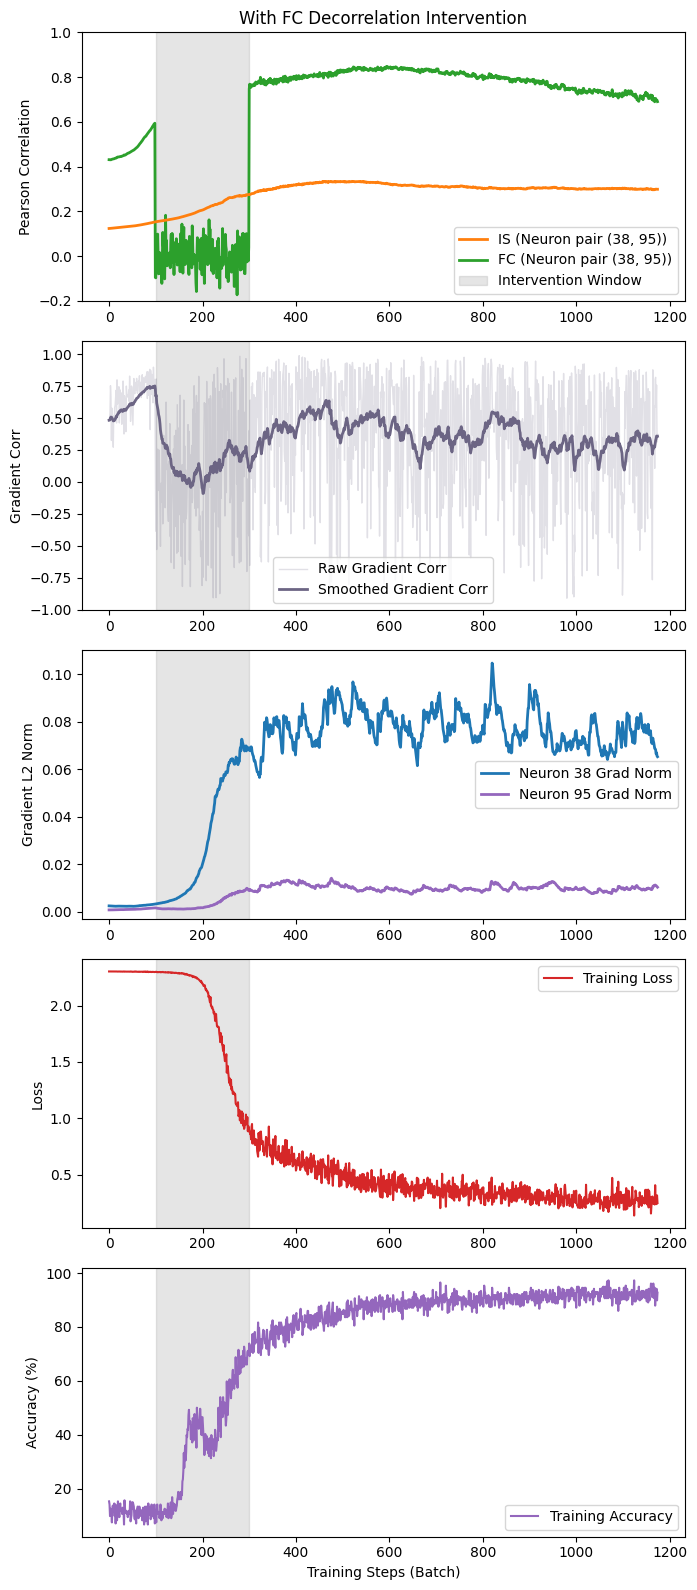

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

import warnings
warnings.filterwarnings('ignore')

# 1. 基础设置与模型定义
def set_seed(seed=42):
    random.seed(seed)                
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False   

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10, activation='relu', init_method='normal'):
        super(MLP, self).__init__()
        self.hidden_dims = hidden_dims
        self.linear_layers = nn.ModuleList()
        layers = []

        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()
        
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(act_fn)
            current_dim = h_dim
        
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        
        self.network = nn.Sequential(*layers)
        
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_method == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

def load_mnist(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=transform, download=True
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    return train_loader

# 2. 核心干预逻辑：基于 Gram-Schmidt 正交化的功能去相关 Hook
class ShuffleDecorrelationIntervention:
    def __init__(self, target_idx_A=0, target_idx_B=1, start_step=50, end_step=300):
        self.target_idx_A = target_idx_A
        self.target_idx_B = target_idx_B
        self.start_step = start_step
        self.end_step = end_step
        self.current_step = 0

    def hook_fn(self, module, input, output):
        if self.start_step <= self.current_step <= self.end_step:
            new_output = output.clone()
            batch_size = output.size(0)
            
            # 生成一个随机排列的索引
            shuffle_idx = torch.randperm(batch_size, device=output.device)
            
            # 仅打乱神经元 B 的批次顺序
            new_output[:, self.target_idx_B] = output[shuffle_idx, self.target_idx_B]
            
            return new_output
        return output

# 3. 带有干预控制和指标追踪的训练循环
def train_model(model, train_loader, epochs=5, learning_rate=0.05, apply_intervention=True, target_pair=(0, 1), intervention_start=50, intervention_end=300):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    # optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    
    model_states = []
    losses = []
    accuracies = []
    grad_corrs = [] # 用于存储梯度相关性
    grad_norms_A = [] # 新增：用于存储神经元A的梯度范数
    grad_norms_B = [] # 新增：用于存储神经元B的梯度范数
    
    if apply_intervention:
        intervention = ShuffleDecorrelationIntervention(target_idx_A=target_pair[0], target_idx_B=target_pair[1], start_step=intervention_start, end_step=intervention_end)
        hook_handle = model.network[3].register_forward_hook(intervention.hook_fn)
        print(f"训练开始 | 设备: {device} | 模式: 开启靶向功能去相关扰动 (强制打乱)")
    else:
        print(f"训练开始 | 设备: {device} | 模式: 正常训练 (无扰动)")

    current_step = 0
    for epoch in range(epochs):
        model.train()
        for batch_idx, (data, targets) in enumerate(train_loader):
            current_step += 1
            if apply_intervention:
                intervention.current_step = current_step
                
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()

            # --- 提取目标神经元的权重梯度并计算相关性和范数 ---
            grad_w = model.linear_layers[1].weight.grad
            if grad_w is not None:
                g_A = grad_w[target_pair[0]].detach().cpu().numpy()
                g_B = grad_w[target_pair[1]].detach().cpu().numpy()
                corr = np.nan_to_num(np.corrcoef(g_A, g_B)[0, 1])
                grad_corrs.append(corr)
                
                # 新增：计算梯度的L2范数，代表梯度向量的长度（变化大小）
                grad_norms_A.append(np.linalg.norm(g_A))
                grad_norms_B.append(np.linalg.norm(g_B))
            else:
                grad_corrs.append(0.0)
                grad_norms_A.append(0.0)
                grad_norms_B.append(0.0)
            # --------------------------------------------------

            optimizer.step()

            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            model_states.append(state)
            
            losses.append(loss.item())
            _, predicted = outputs.max(1)
            acc = 100. * predicted.eq(targets).sum().item() / targets.size(0)
            accuracies.append(acc)
            
    if apply_intervention:
        hook_handle.remove()
        
    return model_states, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B 

def smooth_curve(points, factor=0.85):
    """用于对剧烈波动的数据进行指数滑动平均平滑"""
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# 4. 综合图表绘制 (仅针对 target_pair)
def analyze_comprehensive_effect(models, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B, train_loader, target_pair=(0,1), apply_intervention=True, start_step=50, end_step=300, intervention_obj=None, smooth_factor=0.95):
    sampled_steps = list(range(len(models)))
    target_IS_values = []
    target_FC_values = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data_iter = iter(train_loader)
    fixed_data, _ = next(data_iter)
    fixed_data = fixed_data.to(device).view(fixed_data.size(0), -1)
    
    template_model = MLP(input_size=784, hidden_dims=[100, 100], activation='relu')
    template_model.to(device)
    template_model.eval()
    
    if apply_intervention and intervention_obj is not None:
        hook_handle = template_model.network[3].register_forward_hook(intervention_obj.hook_fn)
    
    for i in range(len(models)):
        state = models[i]
        current_step = i + 1  
        
        if apply_intervention and intervention_obj is not None:
            intervention_obj.current_step = current_step
            
        weights = state['linear_layers.1.weight'].cpu().numpy()
        w_A, w_B = weights[target_pair[0]], weights[target_pair[1]]
        target_IS_values.append(np.nan_to_num(np.corrcoef(w_A, w_B)[0, 1]))

        template_model.load_state_dict(state)
        with torch.no_grad():
            x = fixed_data
            for idx, layer in enumerate(template_model.network):
                x = layer(x)
                if idx == 3:  
                    hidden_acts = x.cpu().numpy()
                    break
            
        act_A = hidden_acts[:, target_pair[0]] + np.random.normal(0, 1e-8, size=fixed_data.shape[0])
        act_B = hidden_acts[:, target_pair[1]] + np.random.normal(0, 1e-8, size=fixed_data.shape[0])
        target_FC_values.append(np.nan_to_num(np.corrcoef(act_A, act_B)[0, 1]))

    if apply_intervention and intervention_obj is not None:
        hook_handle.remove()

    # --- 对各项指标进行平滑处理 ---
    smoothed_grad_corrs = smooth_curve(grad_corrs, factor=smooth_factor)
    smoothed_norm_A = smooth_curve(grad_norms_A, factor=smooth_factor)
    smoothed_norm_B = smooth_curve(grad_norms_B, factor=smooth_factor)

    # 修改为 5 个子图，并增加高度
    fig, (ax1, ax4, ax_norm, ax2, ax3) = plt.subplots(5, 1, figsize=(7, 16), sharex=False)
    
    ax1.plot(sampled_steps, target_IS_values, label=f'IS (Neuron pair {target_pair})', color='tab:orange', linewidth=2, zorder=4)
    ax1.plot(sampled_steps, target_FC_values, label=f'FC (Neuron pair {target_pair})', color='tab:green', linewidth=2)
    if apply_intervention:
        ax1.axvspan(start_step, end_step, color='grey', alpha=0.2, label='Intervention Window')
    ax1.set_ylabel('Pearson Correlation')
    if apply_intervention:
        ax1.set_title('With FC Decorrelation Intervention')
    else:
        ax1.set_title('Without Intervention')
    ax1.legend()
    ax1.set_ylim(-0.2, 1)
    
    # 梯度相关性图
    ax4.plot(sampled_steps, grad_corrs, color='#6C6584', alpha=0.2, linewidth=1, label='Raw Gradient Corr')
    ax4.plot(sampled_steps, smoothed_grad_corrs, color='#6C6584', linewidth=2, label='Smoothed Gradient Corr')
    ax4.set_ylim(-1, 1.1)
    if apply_intervention:
        ax4.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax4.set_ylabel('Gradient Corr')
    ax4.legend()

    # 新增：目标神经元梯度范数（大小）变化图
    # ax_norm.plot(sampled_steps, grad_norms_A, color='tab:blue', alpha=0.2, linewidth=1)
    ax_norm.plot(sampled_steps, smoothed_norm_A, color='tab:blue', linewidth=2, label=f'Neuron {target_pair[0]} Grad Norm')
    # ax_norm.plot(sampled_steps, grad_norms_B, color='tab:purple', alpha=0.2, linewidth=1)
    ax_norm.plot(sampled_steps, smoothed_norm_B, color='tab:purple', linewidth=2, label=f'Neuron {target_pair[1]} Grad Norm')
    if apply_intervention:
        ax_norm.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax_norm.set_ylabel('Gradient L2 Norm')
    ax_norm.legend()
    ax_norm.set_ylim(-0.003, 0.11)

    ax2.plot(sampled_steps, losses, color='tab:red', linewidth=1.5, label='Training Loss')
    if apply_intervention:
        ax2.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    ax3.plot(sampled_steps, accuracies, color='tab:purple', linewidth=1.5, label='Training Accuracy')
    if apply_intervention:
        ax3.axvspan(start_step, end_step, color='grey', alpha=0.2)
    ax3.set_xlabel('Training Steps (Batch)')
    ax3.set_ylabel('Accuracy (%)')
    ax3.legend()
    
    plt.tight_layout()
    plt.savefig(f'./fig/comprehensive_effect_target_pair_{target_pair[0]}_{target_pair[1]}_{"with" if apply_intervention else "without"}_intervention.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# 5. 执行主程序
if __name__ == "__main__":
    set_seed(0)
    train_loader = load_mnist(batch_size=256)
    model = MLP(input_size=784, hidden_dims=[100, 100], activation='relu', init_method='normal')
    
    APPLY_INTERVENTION = True
    target_pair = (38, 95)
    intervention_start = 100
    intervention_end = 300
    
    # 接收新增的 grad_norms_A, grad_norms_B
    model_states, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B = train_model(
        model, train_loader, epochs=5, learning_rate=0.05, 
        apply_intervention=APPLY_INTERVENTION, 
        target_pair=target_pair, 
        intervention_start=intervention_start, 
        intervention_end=intervention_end
    )
    
    intervention_for_analysis = None
    if APPLY_INTERVENTION:
        intervention_for_analysis = ShuffleDecorrelationIntervention(
            target_idx_A=target_pair[0], 
            target_idx_B=target_pair[1], 
            start_step=intervention_start, 
            end_step=intervention_end
        )
    
    # 将 grad_norms_A, grad_norms_B 传入分析函数
    analyze_comprehensive_effect(
        model_states, losses, accuracies, grad_corrs, grad_norms_A, grad_norms_B, train_loader, 
        target_pair=target_pair, 
        apply_intervention=APPLY_INTERVENTION, 
        start_step=intervention_start, 
        end_step=intervention_end,
        intervention_obj=intervention_for_analysis
    )